In [1]:
!pip install BioPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.4 MB/s eta 0:00:00


In [ ]:
# add the csv file of t_dataset_combined.csv
#add the iupred3 , iupred3_lib
# add the data folder


In [ ]:

import sys
!conda install --yes --prefix {sys.prefix} -c bioconda ncbi-blast
!apt-get update
!apt-get install -y ncbi-blast+

/bin/bash: line 1: conda: command not found
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [108 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,557 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,199 kB]
Hit:13 https://ppa.launchpadcon

In [ ]:
# import zipfile
# with zipfile.ZipFile('/content/data.zip', 'r') as z:
#       z.extractall('/content/')

In [ ]:
import sys
sys.path.insert(0, "/content")

import iupred3_lib

In [ ]:
import math
import subprocess
import tempfile
import os

import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint as IP

AA_array = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
            'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Kyte-Doolittle hydrophobicity scale
kd = {"A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5, "Q": -3.5,
      "E": -3.5, "G": -0.4, "H": -3.2, "I": 4.5, "L": 3.8, "K": -3.9,
      "M": 1.9, "F": 2.8, "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9,
      "Y": -1.3, "V": 4.2}

# The 5 residue-class groupings used throughout the paper
Hydrophobic_AAs = ['A', 'I', 'L', 'M', 'F', 'V']
Polar_AAs = ['S', 'Q', 'N', 'G', 'C', 'T', 'P']
Cation_AAs = ['K', 'R', 'H']
Anion_AAs = ['D', 'E']
Arom_AAs = ['W', 'Y', 'F']


def hydrophobicity(seq):
    """Sum of Kyte-Doolittle values over the sequence (Eq. used in paper's Fig. 2B)."""
    sequence = ProteinAnalysis(seq)
    counts = sequence.count_amino_acids()
    return sum(counts[aa] * kd[aa] for aa in AA_array)


def shannon_entropy(seq):
    """H(X) = -sum(p_i * log2(p_i)) over the 20 natural amino acids (paper Eq. 1)."""
    sequence = ProteinAnalysis(seq)
    # NOTE: in current BioPython, amino_acids_percent is on a 0-100 scale,
    # not 0-1 (unlike the older API the original paper code assumed) --
    # must divide by 100 to get a proper probability for Shannon entropy.
    percents = sequence.amino_acids_percent
    entropy = 0
    for aa in AA_array:
        p = percents[aa] / 100
        if p > 0:
            entropy -= p * math.log2(p)
    return entropy


def extract_lcr(seq):
    """
    Low-Complexity Region extraction using the SEG algorithm, invoked
    here via NCBI BLAST+'s `segmasker` command-line tool (this is what
    the original SEG-algorithm reference in the paper corresponds to).
    Returns (number_of_LCR_residues, concatenated_LCR_sequence).
    """
    with tempfile.NamedTemporaryFile(mode='w', suffix='.fasta', delete=False) as f:
        f.write('>seq\n' + seq)
        fasta_path = f.name

    out = subprocess.run(['segmasker', '-in', fasta_path],
                          capture_output=True, text=True)
    tokens = out.stdout.split()[1:]  # drop the leading ">seq"

    starts, ends = [], []
    for i in range(len(tokens) // 3):
        starts.append(int(tokens[3 * i]))
        ends.append(int(tokens[3 * i + 2]))

    lcr_positions = sorted({p for s, e in zip(starts, ends) for p in range(s, e + 1)}) # segmasker positions are 1-indexed (not 0-indexed)
    lcr_sequence = ''.join(seq[p-1] for p in lcr_positions) # adjust to 0-indexed for python string access
    return len(lcr_positions), lcr_sequence


def extract_idr(seq):
    """
    Calculate IDR residues using IUPred3 long disorder mode.

    Score > 0.5 is considered disordered.
    A stretch contributes only if it contains >=20
    consecutive disordered residues.
    """

    # IUPred3 medium smoothing requires >=19 residues.
    # For shorter sequences, use no smoothing.
    smoothing = "medium" if len(seq) >= 19 else "no"

    probs = iupred3_lib.iupred(
        seq,
        mode="long",
        smoothing=smoothing
    )[0]

    THRESHOLD = 0.5
    MIN_STRETCH = 20

    idr_residue_count = 0
    current = 0

    for p in probs:

        if p > THRESHOLD:
            current += 1
        else:
            if current >= MIN_STRETCH:
                idr_residue_count += current

            current = 0

    # Handle stretch reaching the end
    if current >= MIN_STRETCH:
        idr_residue_count += current

    return idr_residue_count


def get_aa_count(seq, aa):
    return ProteinAnalysis(seq).count_amino_acids()[aa]


def compute_features(df, seq_col='Sequence'):
    df = df.copy()
    df['Sequence_length'] = df[seq_col].str.len()

    print("  computing LCRs (segmasker)...")
    lcr_results = [extract_lcr(s) for s in df[seq_col]]
    df['LCR_length'] = [r[0] for r in lcr_results]
    df['LCR_sequence'] = [r[1] for r in lcr_results]
    df['LCR_frac'] = df['LCR_length'] / df['Sequence_length']

    print("  computing hydrophobicity / Shannon entropy / pI...")
    df['Hydrophobicity'] = [hydrophobicity(s) for s in df[seq_col]]
    df['Shannon_entropy'] = [shannon_entropy(s) for s in df[seq_col]]
    df['pI'] = [IP(s).pi() for s in df[seq_col]]

    print("  computing IDRs (IUPred2a)...")
    idr_results = []

    for i, seq in enumerate(df[seq_col]):
        idr_results.append(extract_idr(seq))

        if (i + 1) % 100 == 0:
            print(f"    IDR: {i + 1}/{len(df)}")

    df['IDR_residues'] = idr_results
    df['IDR_frac'] = df['IDR_residues'] / df['Sequence_length']

    print("  computing amino acid composition (full sequence)...")
    for aa in AA_array:
        df[f'AA_{aa}'] = [get_aa_count(s, aa) for s in df[seq_col]]

    df['HB'] = df[[f'AA_{a}' for a in Hydrophobic_AAs]].sum(axis=1)
    df['Polar'] = df[[f'AA_{a}' for a in Polar_AAs]].sum(axis=1)
    df['Arom'] = df[[f'AA_{a}' for a in Arom_AAs]].sum(axis=1)
    df['Cation'] = df[[f'AA_{a}' for a in Cation_AAs]].sum(axis=1)
    df['Anion'] = df[[f'AA_{a}' for a in Anion_AAs]].sum(axis=1)
    for name in ['HB', 'Polar', 'Arom', 'Cation', 'Anion']:
        df[f'{name}_frac'] = (df[name] / df['Sequence_length']).fillna(0)

    print("  computing amino acid composition (within LCRs only)...")
    for aa in AA_array:
        df[f'AA_LCR_{aa}'] = [get_aa_count(s, aa) if len(s) > 0 else 0 for s in df['LCR_sequence']]

    df['HB_LCR'] = df[[f'AA_LCR_{a}' for a in Hydrophobic_AAs]].sum(axis=1)
    df['Polar_LCR'] = df[[f'AA_LCR_{a}' for a in Polar_AAs]].sum(axis=1)
    df['Arom_LCR'] = df[[f'AA_LCR_{a}' for a in Arom_AAs]].sum(axis=1)
    df['Cation_LCR'] = df[[f'AA_LCR_{a}' for a in Cation_AAs]].sum(axis=1)
    df['Anion_LCR'] = df[[f'AA_LCR_{a}' for a in Anion_AAs]].sum(axis=1)
    for name in ['HB_LCR', 'Polar_LCR', 'Arom_LCR', 'Cation_LCR', 'Anion_LCR']:
        df[f'{name}_frac'] = (df[name] / df['LCR_length']).fillna(0)

    df = df.drop(columns=['LCR_sequence'])
    return df


if __name__ == '__main__':
    training_data = pd.read_csv('/content/training_dataset_combined.csv')
    print(f"Loaded {training_data.shape[0]} sequences to featurize")

    featurized = compute_features(training_data)

    featurized.to_csv('training_data_EF_features.csv', index=False)

    print()
    print(f"Done. Feature table shape: {featurized.shape}")
    print(featurized[['Sequence', 'Category', 'Sequence_length', 'Hydrophobicity',
                       'Shannon_entropy', 'LCR_frac', 'IDR_frac',
                       'Polar_frac', 'HB_frac', 'Arom_frac', 'Cation_frac',
                       'Anion_frac']].head())

Loaded 1783 sequences to featurize
  computing LCRs (segmasker)...
  computing hydrophobicity / Shannon entropy / pI...
  computing IDRs (IUPred2a)...
    IDR: 100/1783
    IDR: 200/1783
    IDR: 300/1783
    IDR: 400/1783
    IDR: 500/1783
    IDR: 600/1783
    IDR: 700/1783
    IDR: 800/1783
    IDR: 900/1783
    IDR: 1000/1783
    IDR: 1100/1783
    IDR: 1200/1783
    IDR: 1300/1783
    IDR: 1400/1783
    IDR: 1500/1783
    IDR: 1600/1783
    IDR: 1700/1783
  computing amino acid composition (full sequence)...
  computing amino acid composition (within LCRs only)...

Done. Feature table shape: (1783, 71)
                                            Sequence Category  \
0  AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...    LLPS+   
1  ASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDT...    LLPS+   
2  CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...    LLPS+   
3  DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...    LLPS+   
4  EHHSGSQGPLLTTGDLGKEKTQKRVKEGNGTSNSTLSGPGLDSKPG...    LLPS

To resolve the `FileNotFoundError` for `segmasker`, we need to install NCBI BLAST+, which includes the `segmasker` utility. We will use `conda` via `mamba` to install `ncbi-blast`.

In [ ]:
# diagrams generations

Saved llps_plus_feature_histograms.png (n=135 LLPS+ proteins)


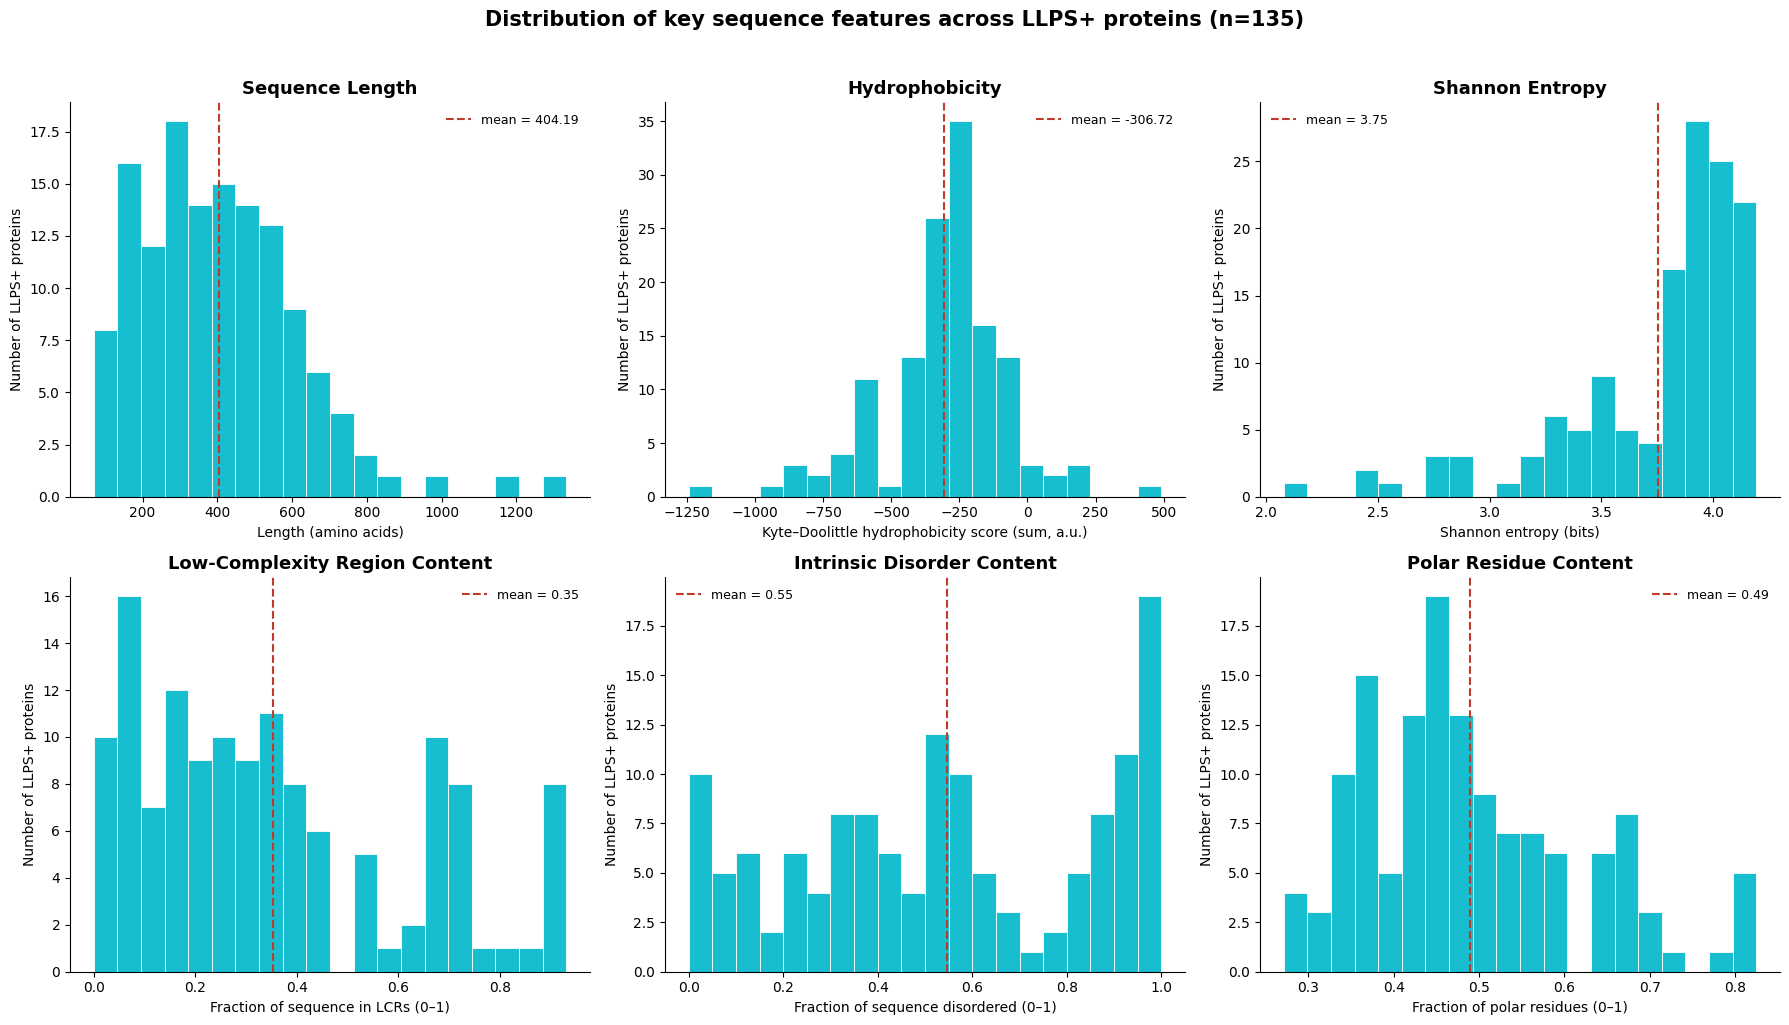

In [ ]:
"""
STEP 4 (corrected): Histogram of LLPS+ proteins for 6 key features.

x-axis = feature value (with proper physical units)
y-axis = number of LLPS+ proteins (count)
"""
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/training_data_EF_features.csv')
llps_plus = df[df['Category'] == 'LLPS+']
n = len(llps_plus)

# (column, title, x-axis label WITH units, number of bins, mean-line color)
FEATURES = [
    ('Sequence_length', 'Sequence Length', 'Length (amino acids)', 20),
    ('Hydrophobicity', 'Hydrophobicity', 'Kyte–Doolittle hydrophobicity score (sum, a.u.)', 20),
    ('Shannon_entropy', 'Shannon Entropy', 'Shannon entropy (bits)', 20),
    ('LCR_frac', 'Low-Complexity Region Content', 'Fraction of sequence in LCRs (0–1)', 20),
    ('IDR_frac', 'Intrinsic Disorder Content', 'Fraction of sequence disordered (0–1)', 20),
    ('Polar_frac', 'Polar Residue Content', 'Fraction of polar residues (0–1)', 20),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title, xlabel, bins) in zip(axes, FEATURES):
    vals = llps_plus[col]
    ax.hist(vals, bins=bins, color='#17becf', edgecolor='white', linewidth=0.6)
    mean_val = vals.mean()
    ax.axvline(mean_val, color='#c0392b', linestyle='--', linewidth=1.5,
               label=f'mean = {mean_val:.2f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Number of LLPS+ proteins', fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Distribution of key sequence features across LLPS+ proteins (n={n})',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('llps_plus_feature_histograms.png', dpi=200, bbox_inches='tight')
print(f"Saved llps_plus_feature_histograms.png (n={n} LLPS+ proteins)")

In [2]:
# Just finding the comparative study of LLPS+ LLPS- and PDB. How they differ.

In [3]:
# this section of code and run independently, Just add the
#training_data_EF_features.csv

Statistical summary (feature vs feature):
        Feature Group_A Group_B    Median_A    Median_B       p_value significance
Sequence_length   LLPS+   LLPS-  383.000000  221.500000  7.004894e-06         ****
Sequence_length   LLPS+    PDB*  383.000000  194.000000  2.984901e-24         ****
Sequence_length   LLPS-    PDB*  221.500000  194.000000  4.975492e-03           **
 Hydrophobicity   LLPS+   LLPS- -274.700000 -181.650000  4.775840e-06         ****
 Hydrophobicity   LLPS+    PDB* -274.700000  -42.600000  4.040997e-53         ****
 Hydrophobicity   LLPS-    PDB* -181.650000  -42.600000  1.890090e-27         ****
Shannon_entropy   LLPS+   LLPS-    3.911757    3.894736  8.536320e-01           ns
Shannon_entropy   LLPS+    PDB*    3.911757    4.025676  3.720701e-15         ****
Shannon_entropy   LLPS-    PDB*    3.894736    4.025676  1.904182e-09         ****
       LCR_frac   LLPS+   LLPS-    0.307143    0.142172  3.880355e-04          ***
       LCR_frac   LLPS+    PDB*    0.307143  

/tmp/ipykernel_1577/331577866.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CATS, patch_artist=True, showfliers=True,
/tmp/ipykernel_1577/331577866.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CATS, patch_artist=True, showfliers=True,
/tmp/ipykernel_1577/331577866.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=CATS, patch_artist=True, showfliers=True,
/tmp/ipykernel_1577/331577866.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support


Saved comparative_boxplots.png
Saved composition_comparison.png


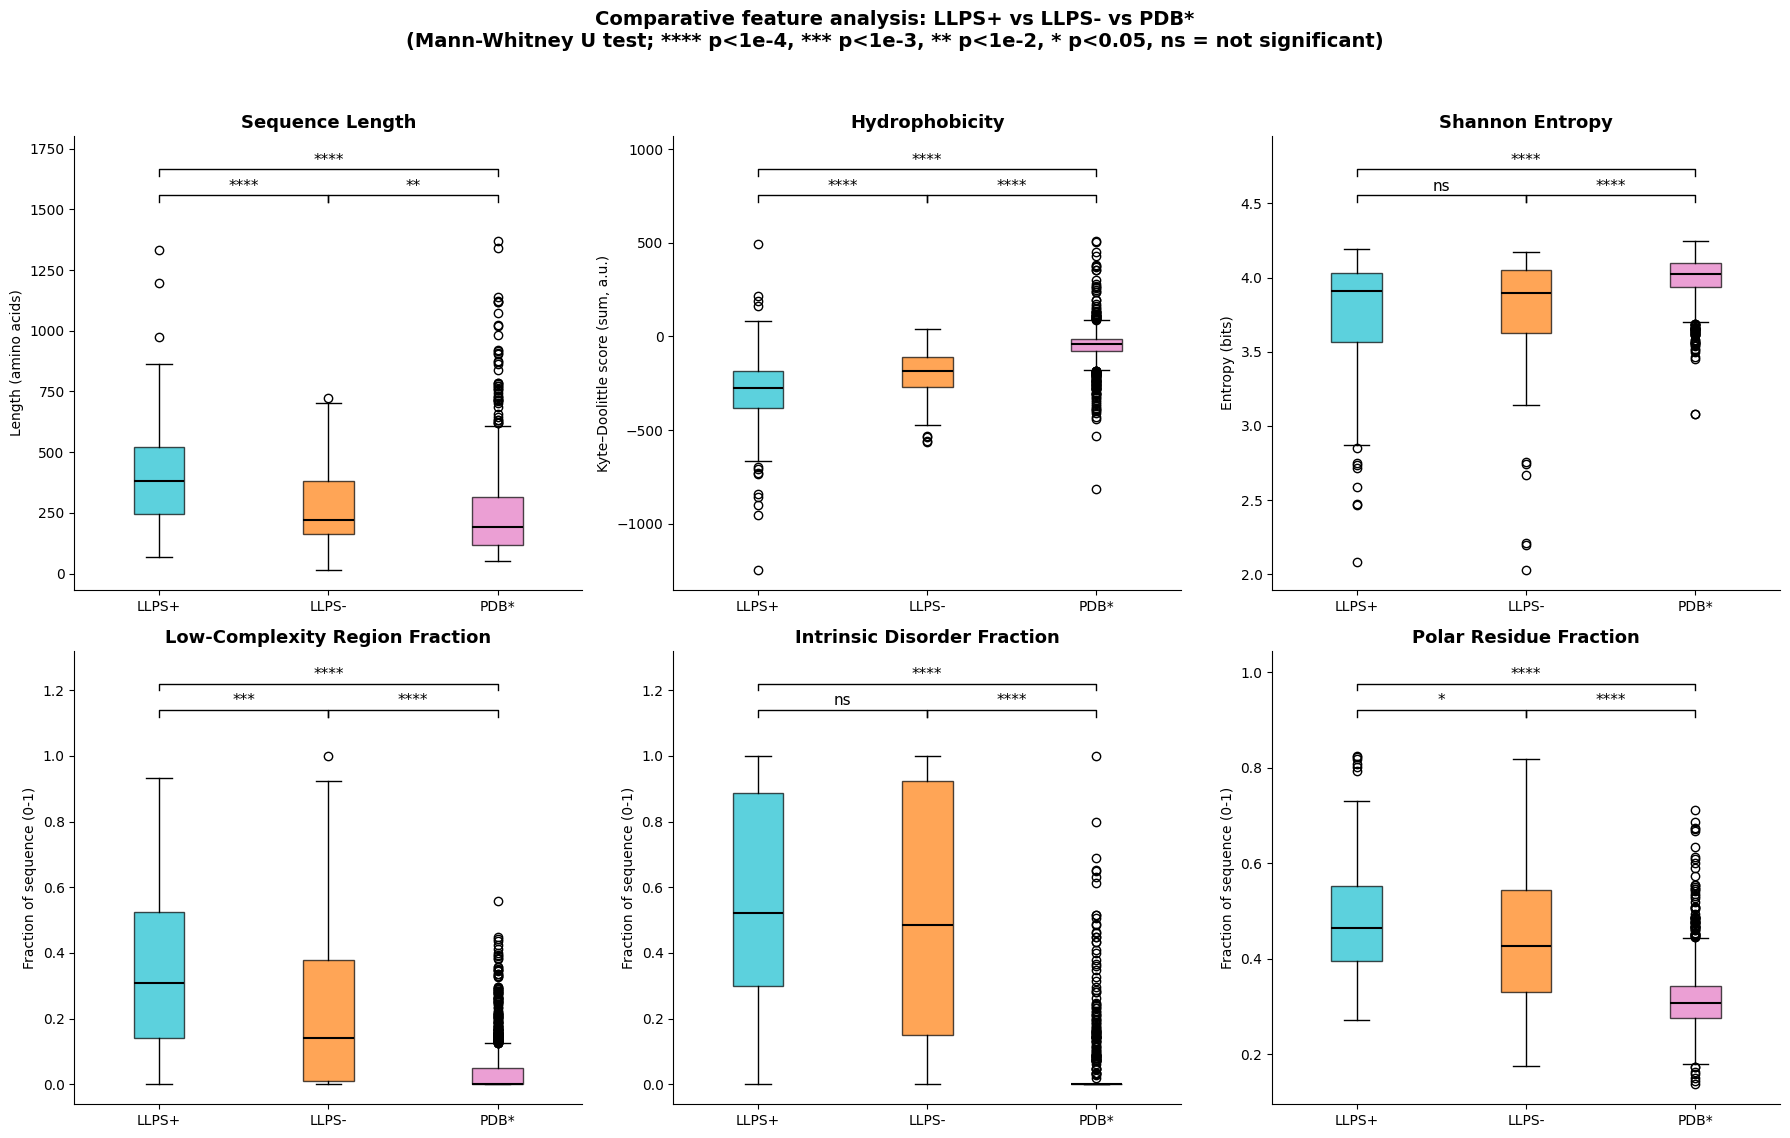

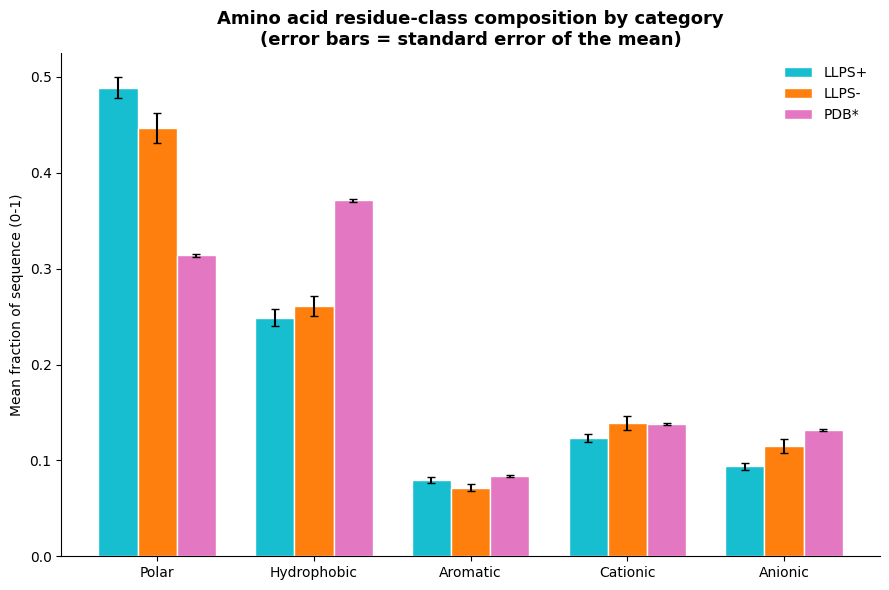

In [5]:
"""
Comparative Analysis: LLPS+ vs LLPS- vs PDB*
=============================================
Question: Do a comparative analysis that actually distinguishes
LLPS+ from LLPS- and PDB* (not just plot them side by side, but
statistically test whether the differences are real).

This mirrors the paper's own approach (Fig. 2 / Fig. 3): box plots
across the three categories, with pairwise Mann-Whitney U tests
(matching the paper's stated method) and effect sizes.

Output:
  - comparative_boxplots.png   : 6 key features, 3-way comparison
  - composition_comparison.png : mean residue-class composition per category
  - comparative_stats_summary.csv : full numeric test results
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

df = pd.read_csv('/content/training_data_EF_features.csv')
CATS = ['LLPS+', 'LLPS-', 'PDB*']
COLORS = {'LLPS+': '#17becf', 'LLPS-': '#ff7f0e', 'PDB*': '#e377c2'}
PAIRS = [('LLPS+', 'LLPS-'), ('LLPS+', 'PDB*'), ('LLPS-', 'PDB*')]

FEATURES = [
    ('Sequence_length', 'Sequence Length', 'Length (amino acids)'),
    ('Hydrophobicity', 'Hydrophobicity', 'Kyte–Doolittle score (sum, a.u.)'),
    ('Shannon_entropy', 'Shannon Entropy', 'Entropy (bits)'),
    ('LCR_frac', 'Low-Complexity Region Fraction', 'Fraction of sequence (0-1)'),
    ('IDR_frac', 'Intrinsic Disorder Fraction', 'Fraction of sequence (0-1)'),
    ('Polar_frac', 'Polar Residue Fraction', 'Fraction of sequence (0-1)'),
]


def stars(p):
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def cliffs_delta(a, b):
    """Effect size: fraction of pairs favoring a minus fraction favoring b.
    Ranges -1..1; |d|<0.147 negligible, <0.33 small, <0.474 medium, else large
    (Romano et al. 2006 thresholds)."""
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((x > b).sum() for x in a)
    lt = sum((x < b).sum() for x in a)
    return (gt - lt) / (len(a) * len(b))


# ---------------------------------------------------------------
# 1) STATISTICAL TESTING: Mann-Whitney U test for every feature,
#    for every pair of categories. Non-parametric, matches the
#    paper's own stated significance test (they use Mann-Whitney
#    for exactly this kind of category comparison).
# ---------------------------------------------------------------
all_feature_cols = [f[0] for f in FEATURES] + ['HB_frac', 'Arom_frac', 'Cation_frac', 'Anion_frac']
results = []
for col in all_feature_cols:
    for cat_a, cat_b in PAIRS:
        a = df.loc[df['Category'] == cat_a, col].dropna()
        b = df.loc[df['Category'] == cat_b, col].dropna()
        u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
        delta = cliffs_delta(a.values, b.values)
        results.append({
            'Feature': col, 'Group_A': cat_a, 'Group_B': cat_b,
            'Median_A': a.median(), 'Median_B': b.median(),
            'Mann_Whitney_U': u_stat, 'p_value': p_val,
            'significance': stars(p_val),
            "Cliffs_delta": delta,
        })

stats_df = pd.DataFrame(results)
stats_df.to_csv('comparative_stats_summary.csv', index=False)
print("Statistical summary (feature vs feature):")
print(stats_df[['Feature', 'Group_A', 'Group_B', 'Median_A', 'Median_B', 'p_value', 'significance']].to_string(index=False))

# ---------------------------------------------------------------
# 2) BOX PLOTS with significance bars, for the 6 headline features
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (col, title, ylabel) in zip(axes, FEATURES):
    data = [df.loc[df['Category'] == c, col].dropna().values for c in CATS]
    bp = ax.boxplot(data, labels=CATS, patch_artist=True, showfliers=True,
                     medianprops=dict(color='black', linewidth=1.5))
    for patch, cat in zip(bp['boxes'], CATS):
        patch.set_facecolor(COLORS[cat])
        patch.set_alpha(0.7)

    # significance bars between each pair, stacked above the data
    y_max = max(d.max() for d in data)
    y_min = min(d.min() for d in data)
    y_range = y_max - y_min
    bar_positions = {('LLPS+', 'LLPS-'): (1, 2, 0.06),
                      ('LLPS+', 'PDB*'): (1, 3, 0.14),
                      ('LLPS-', 'PDB*'): (2, 3, 0.06)}
    for (cat_a, cat_b), (x1, x2, offset_frac) in bar_positions.items():
        row = stats_df[(stats_df['Feature'] == col) &
                        (stats_df['Group_A'] == cat_a) & (stats_df['Group_B'] == cat_b)]
        sig = row['significance'].values[0]
        y = y_max + y_range * (0.06 + offset_frac)
        ax.plot([x1, x1, x2, x2], [y, y + y_range * 0.02, y + y_range * 0.02, y], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, y + y_range * 0.025, sig, ha='center', va='bottom', fontsize=11)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(top=y_max + y_range * 0.32)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Comparative feature analysis: LLPS+ vs LLPS- vs PDB*\n(Mann-Whitney U test; **** p<1e-4, *** p<1e-3, ** p<1e-2, * p<0.05, ns = not significant)',
             fontsize=14, fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig('comparative_boxplots.png', dpi=200, bbox_inches='tight')
print("\nSaved comparative_boxplots.png")

# ---------------------------------------------------------------
# 3) AMINO ACID COMPOSITION COMPARISON (mirrors paper Fig. 3A)
# ---------------------------------------------------------------
comp_cols = ['Polar_frac', 'HB_frac', 'Arom_frac', 'Cation_frac', 'Anion_frac']
comp_labels = ['Polar', 'Hydrophobic', 'Aromatic', 'Cationic', 'Anionic']

fig2, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(comp_cols))
width = 0.25
for i, cat in enumerate(CATS):
    means = [df.loc[df['Category'] == cat, c].mean() for c in comp_cols]
    sems = [df.loc[df['Category'] == cat, c].sem() for c in comp_cols]
    ax.bar(x + (i - 1) * width, means, width, yerr=sems, capsize=3,
           label=cat, color=COLORS[cat], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comp_labels)
ax.set_ylabel('Mean fraction of sequence (0-1)')
ax.set_title('Amino acid residue-class composition by category\n(error bars = standard error of the mean)',
              fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig2.tight_layout()
fig2.savefig('composition_comparison.png', dpi=200, bbox_inches='tight')
print("Saved composition_comparison.png")

Saved correlation_heatmap.png

Strongest feature-feature correlations (|rho| > 0.5, excluding diagonal):
  Hydrophobicity     vs HB_frac             rho = +0.731
  Polar_frac         vs Anion_frac          rho = -0.578
  pI                 vs Anion_frac          rho = -0.547
  Polar_frac         vs HB_frac             rho = -0.527
  pI                 vs Cation_frac         rho = +0.521

Univariate AUROC summary:
          Task         Feature    AUROC  Discriminative_power
 LLPS+ vs PDB* Sequence_length 0.763193              0.763193
 LLPS+ vs PDB*  Hydrophobicity 0.102589              0.897411
 LLPS+ vs PDB* Shannon_entropy 0.296287              0.703713
 LLPS+ vs PDB*              pI 0.701847              0.701847
 LLPS+ vs PDB*        LCR_frac 0.917186              0.917186
 LLPS+ vs PDB*        IDR_frac 0.953324              0.953324
 LLPS+ vs PDB*      Polar_frac 0.914786              0.914786
 LLPS+ vs PDB*         HB_frac 0.122168              0.877832
 LLPS+ vs PDB*       Arom

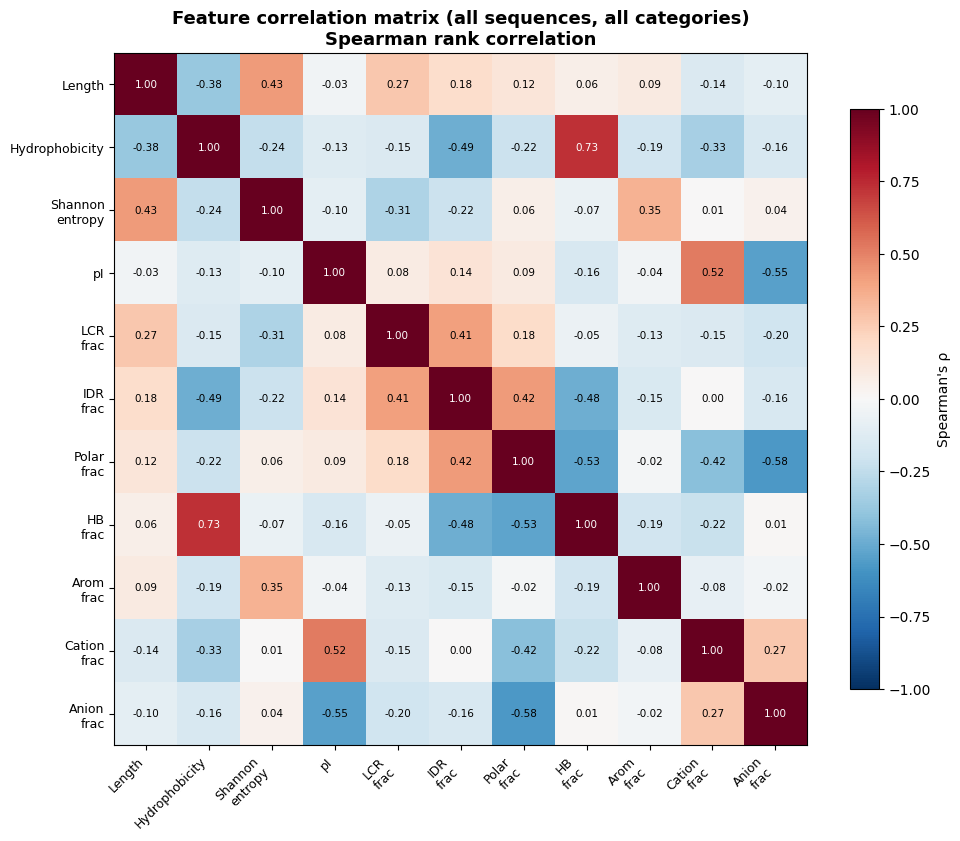

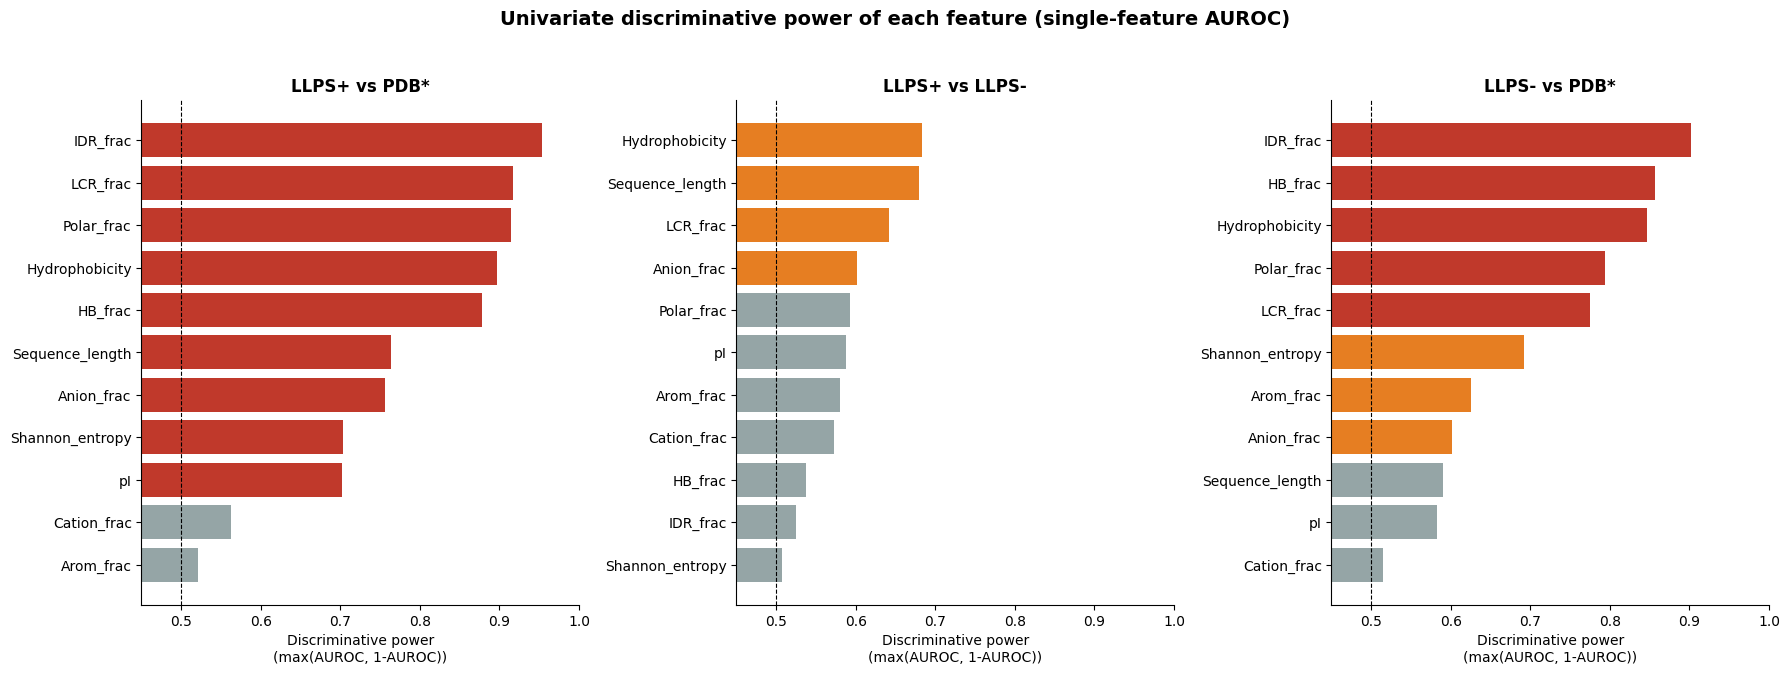

In [6]:
"""
Correlation + Univariate Feature Analysis
==========================================
Question: (1) How correlated are the engineered features with each
other (redundancy / multicollinearity check before modeling)?
(2) How much discriminative power does EACH feature carry on its
own, in isolation, before any model combines them?

Output:
  - correlation_heatmap.png       : Spearman correlation between all features
  - univariate_auroc.png          : per-feature AUROC for two binary tasks
  - correlation_matrix.csv        : full numeric correlation matrix
  - univariate_auroc_summary.csv  : full numeric AUROC results
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

df = pd.read_csv('/content/training_data_EF_features.csv')

FEATURES = ['Sequence_length', 'Hydrophobicity', 'Shannon_entropy', 'pI',
            'LCR_frac', 'IDR_frac',
            'Polar_frac', 'HB_frac', 'Arom_frac', 'Cation_frac', 'Anion_frac']

FEATURE_LABELS = ['Length', 'Hydrophobicity', 'Shannon\nentropy', 'pI',
                   'LCR\nfrac', 'IDR\nfrac',
                   'Polar\nfrac', 'HB\nfrac', 'Arom\nfrac', 'Cation\nfrac', 'Anion\nfrac']

# =================================================================
# PART 1: CORRELATION ANALYSIS
# Spearman rank correlation is used (not Pearson) because several
# of these features (fractions, entropy) are not normally
# distributed and Spearman is robust to that -- it only assumes a
# monotonic, not linear, relationship.
# =================================================================
corr = df[FEATURES].corr(method='spearman')
corr.to_csv('correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURE_LABELS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(FEATURE_LABELS, fontsize=9)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Spearman's ρ", fontsize=10)
ax.set_title('Feature correlation matrix (all sequences, all categories)\nSpearman rank correlation',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
print("Saved correlation_heatmap.png")

# Flag the strongest off-diagonal correlations
print("\nStrongest feature-feature correlations (|rho| > 0.5, excluding diagonal):")
pairs_seen = set()
strong_pairs = []
for i, f1 in enumerate(FEATURES):
    for j, f2 in enumerate(FEATURES):
        if i < j and abs(corr.iloc[i, j]) > 0.5:
            strong_pairs.append((f1, f2, corr.iloc[i, j]))
strong_pairs.sort(key=lambda x: -abs(x[2]))
for f1, f2, rho in strong_pairs:
    print(f"  {f1:18s} vs {f2:18s}  rho = {rho:+.3f}")

# =================================================================
# PART 2: UNIVARIATE FEATURE ANALYSIS
# For each feature, in isolation, measure how well it alone
# separates two classes -- using the feature's raw value as a
# 1D "classifier score" and computing AUROC. This tells us each
# feature's standalone discriminative power BEFORE any model
# combines them -- useful for sanity-checking that a Random
# Forest's later feature-importance ranking makes sense.
#
# AUROC of exactly 0.5 = no discriminative power (random).
# AUROC far from 0.5 in EITHER direction = strong single-feature
# signal (we report max(AUROC, 1-AUROC) as "discriminative power"
# so direction doesn't matter, only strength).
# =================================================================
TASKS = {
    'LLPS+ vs PDB*': ('LLPS+', 'PDB*'),
    'LLPS+ vs LLPS-': ('LLPS+', 'LLPS-'),
    'LLPS- vs PDB*': ('LLPS-', 'PDB*'),
}

univariate_results = []
for task_name, (pos_cat, neg_cat) in TASKS.items():
    sub = df[df['Category'].isin([pos_cat, neg_cat])].copy()
    y = (sub['Category'] == pos_cat).astype(int)
    for feat in FEATURES:
        x = sub[feat]
        auc = roc_auc_score(y, x)
        discriminative_power = max(auc, 1 - auc)
        univariate_results.append({
            'Task': task_name, 'Feature': feat,
            'AUROC': auc, 'Discriminative_power': discriminative_power,
            'Direction': f'higher {feat} -> more likely {pos_cat}' if auc >= 0.5
                         else f'higher {feat} -> more likely {neg_cat}',
        })

uni_df = pd.DataFrame(univariate_results)
uni_df.to_csv('univariate_auroc_summary.csv', index=False)
print("\nUnivariate AUROC summary:")
print(uni_df[['Task', 'Feature', 'AUROC', 'Discriminative_power']].to_string(index=False))

# ---------------------------------------------------------------
# Plot: ranked bar charts of discriminative power per task
# ---------------------------------------------------------------
fig2, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharex=True)
for ax, task_name in zip(axes, TASKS.keys()):
    sub = uni_df[uni_df['Task'] == task_name].sort_values('Discriminative_power')
    colors = ['#c0392b' if p > 0.7 else ('#e67e22' if p > 0.6 else '#95a5a6')
              for p in sub['Discriminative_power']]
    ax.barh(sub['Feature'], sub['Discriminative_power'], color=colors)
    ax.axvline(0.5, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlim(0.45, 1.0)
    ax.set_xlabel('Discriminative power\n(max(AUROC, 1-AUROC))')
    ax.set_title(task_name, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig2.suptitle('Univariate discriminative power of each feature (single-feature AUROC)',
              fontsize=14, fontweight='bold', y=1.03)
fig2.tight_layout()
fig2.savefig('univariate_auroc.png', dpi=200, bbox_inches='tight')
print("\nSaved univariate_auroc.png")